# Experiment 1: Skill Frequency in Data Science Job Postings

Core skills such as Python, SQL, and statistics will have the highest frequency across job postings, indicating baseline requirements for data science roles -- does it supports by the real world data? 

This notebook tests the hypothesis that core skills such as Python, SQL, and statistics appear most frequently across data science job postings.


In [ ]:
# !pip install pandas
# !pip install matplotlib

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [16]:
data_path = Path("data/glassdoor_jobs.csv")
df = pd.read_csv(data_path)

required_column = "Job Description"
if required_column not in df.columns:
    raise ValueError(f"Expected '{required_column}' column in {data_path}.")

job_descriptions = df[required_column].fillna("").astype(str)
print(f"Loaded {len(df)} job postings from {data_path}.")

Loaded 1500 job postings from data\glassdoor_jobs.csv.


In [17]:
df.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Size,Founded,Type of ownership,Industry,Sector,Revenue
0,Data Scientist,-1,Job Overview\nA Data Scientist at ExploreLearn...,4.2,Cambium Learning Group\n4.3,Remote,1001 to 5000 Employees,2004,Company - Private,Primary & Secondary Schools,Education,$500 million to $1 billion (USD)
1,2024 University Graduate - Data Scientist,Employer Provided Salary:$83K - $153K,Our Company\n\nChanging the world through digi...,4.4,Adobe\n4.4,"San Jose, CA",10000+ Employees,1982,Company - Public,Computer Hardware Development,Information Technology,$5 to $10 billion (USD)
2,Data Scientist – Entry Level 2024,Employer Provided Salary:$71K - $133K,Introduction\nRanked by Forbes as one of the w...,3.9,IBM\n3.9,"Atlanta, GA",10000+ Employees,1911,Company - Public,Information Technology Support Services,Information Technology,$10+ billion (USD)
3,Data Scientist 2,Employer Provided Salary:$94K - $183K,The Microsoft 365 team is looking for a Data S...,4.3,Microsoft\n4.3,"Redmond, WA",10000+ Employees,1975,Company - Public,Computer Hardware Development,Information Technology,$10+ billion (USD)
4,Entry Level Data Scientist 2023/2024,$48K - $78K (Glassdoor est.),"You may not realize it, but you’ve likely used...",3.9,CPChem\n3.9,"The Woodlands, TX",1001 to 5000 Employees,2000,Company - Private,Chemical Manufacturing,Manufacturing,$10+ billion (USD)


In [18]:
df.tail()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Size,Founded,Type of ownership,Industry,Sector,Revenue
1495,Global Technology Transformation Analytics Vic...,Employer Provided Salary:$128K - $190K,JOB DESCRIPTION\n\nThe Global Technology Trans...,4.0,JPMorgan Chase & Co\n4.0,"New York, NY",10000+ Employees,1799,Company - Public,Banking & Lending,Financial Services,$10+ billion (USD)
1496,Senior Data Scientist,Employer Provided Salary:$145K,Job Summary:\nWe are seeking a talented and ex...,4.3,Cydcor\n4.3,"Agoura Hills, CA",51 to 200 Employees,1994,Company - Private,Advertising & Public Relations,Media & Communication,$5 to $25 million (USD)
1497,Remote - Data Scientist,Employer Provided Salary:$79K - $120K,"We’re looking for talented professionals, anyw...",3.0,Green Dot Corporation\n3.1,Remote,1001 to 5000 Employees,1999,Company - Public,Financial Transaction Processing,Financial Services,$1 to $5 billion (USD)
1498,Market Data Analyst,$53K - $77K (Glassdoor est.),Summary:\n**PLEASE NOTE - This is NOT a techni...,-1.0,S4 Market Data,"Trenton, NJ",Unknown,-1,Company - Private,Information Technology Support Services,Information Technology,Unknown / Non-Applicable
1499,Data Scientist,$94K - $132K (Glassdoor est.),The University of Iowa is seeking a Data Scien...,3.9,The University of Iowa\n3.9,"Iowa City, IA",10000+ Employees,1898,Hospital,Health Care Services & Hospitals,Healthcare,$1 to $5 billion (USD)


In [12]:
skill_patterns = {
    "Machine Learning": r"\bmachine learning\b",
    "Statistics": r"\bstatistic(?:s|al)?\b",
    "Python": r"\bpython\b",
    "R": r"(?<![A-Za-z0-9])R(?![A-Za-z0-9])",
    "SQL": r"\bsql\b",
    "NLP": r"\bnlp\b|natural language processing",
    "Tableau": r"\btableau\b",
    "AWS": r"\baws\b|amazon web services",
    "SAS": r"\bsas\b",
    "Excel": r"\bexcel\b",
}

posting_count = len(job_descriptions)
frequency_rows = []

for skill, pattern in skill_patterns.items():
    mention_count = job_descriptions.str.contains(pattern, case=False, regex=True).sum()
    frequency_rows.append(
        {
            "Skill": skill,
            "Mention Count": int(mention_count),
            "Percentage of Postings": round(mention_count / posting_count * 100, 2),
        }
    )

skill_frequency = (
    pd.DataFrame(frequency_rows)
    .sort_values(by="Mention Count", ascending=False)
    .reset_index(drop=True)
)

skill_frequency

,Skill,Mention Count,Percentage of Postings
0,Machine Learning,375,25.00
1,Statistics,320,21.33
2,Python,156,10.40
3,R,106,7.07
4,NLP,92,6.13
5,SQL,90,6.00
6,Tableau,52,3.47
7,AWS,35,2.33
8,SAS,34,2.27
9,Excel,32,2.13


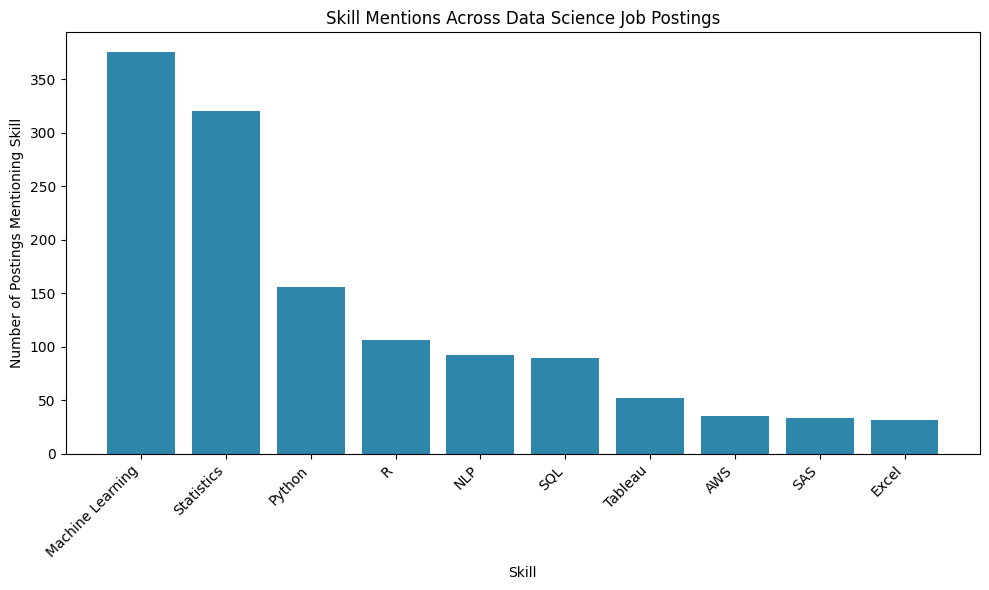

In [13]:
plt.figure(figsize=(10, 6))
plt.bar(skill_frequency["Skill"], skill_frequency["Mention Count"], color="#2E86AB")
plt.title("Skill Mentions Across Data Science Job Postings")
plt.xlabel("Skill")
plt.ylabel("Number of Postings Mentioning Skill")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [14]:
core_skills = skill_frequency[skill_frequency["Skill"].isin(["Python", "SQL", "Statistics"])]
core_skills

,Skill,Mention Count,Percentage of Postings
1,Statistics,320,21.33
2,Python,156,10.40
5,SQL,90,6.00


## Interpretation

The hypothesis is **partially supported** by this dataset. Statistics-related terms and Python are frequent baseline skills in data science postings, but SQL is not among the very highest-frequency mentions. Instead, machine learning appears most often in the job descriptions.

With the current data, the ranking is expected to look approximately like this:

- Machine Learning: about 375 postings
- Statistics: about 320 postings
- Python: about 156 postings
- SQL: about 90 postings

This suggests that Python and statistics are strong baseline requirements, while SQL remains important but less dominant than the original hypothesis predicted.